## Basics

In [20]:
#import relevant libraries
import os
from scipy import stats
import numpy as np
import scipy as sp
import pandas as pd
import NLProcessing
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm
import seaborn as sns
import dabest
import NLCLIMB
import NLMATH
import itertools
from datetime import datetime


date = datetime.today().strftime('%Y%m%d')
from statistics import mean
from textwrap import wrap
import dabest
import plotly.express as px 
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.graph_objects import Layout
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import osar 

#NOTE: SUPPRESSES WARNINGS!

import warnings
warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

print(osar.__version__)

0.23.9


In [21]:
officecomp = "C:\\Users\\Star\\"
labcomp = "C:\\Users\\User\\"
computer2 = "C:\\Users\\lnico\\"
homecomp = "D:\\"
specifiedpath = homecomp
filedate = "20260617"

filedirectory_OSAR = "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\2025collection\\"
filedirectory_Climbing = "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Climbing_New\\Compilation with delta\\2025deltagcollection\\"
filesavedir = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Totalosarclimbing\\images\\"

In [22]:
#for fonts only
import matplotlib.pyplot as plt
from matplotlib import font_manager

font_dirs = ["fonts"]  # The path to the custom font file.
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)


for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
    prop = font_manager.FontProperties(fname=font_file)

availablefonts = [f.name for f in matplotlib.font_manager.fontManager.ttflist]
plt.rcParams["font.family"] = "Inter"

## Function

In [23]:
import textwrap


## Formulas to run


In [24]:
climbingexcel = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar climbing\\Climbing_" + filedate + ".xlsx")
MBONList = list(climbingexcel['MBON'].unique())

lobelocation = NLProcessing.generate_lobelocation(MBONList, "MBONlist.csv")

## Heatmap for specific MBONs comparing PI and so forth

In [6]:
singlecellmbon = ['MB018B',
'MB080C',
'MB085C',
'MB091C',
'MB112C',
'MB242A',
'MB262B',
'MB298B',
'MB399B',
'MB622B',
'SS01127',
'SS01143',
'SS01188',
'SS01194',
'SS01308',
'SS01337',
'SS01388',
'SS46348',
'SS67662',
'SS67727',
'SS67728',
'SS67741',
'SS67755',
'SS75199',
'SS75200',
'SS76094',
'SS77383',
'SS77424',
'SS77450',
'SS80974',
'SS81353',
'SS81521',
'SS95118',
'SS97567']


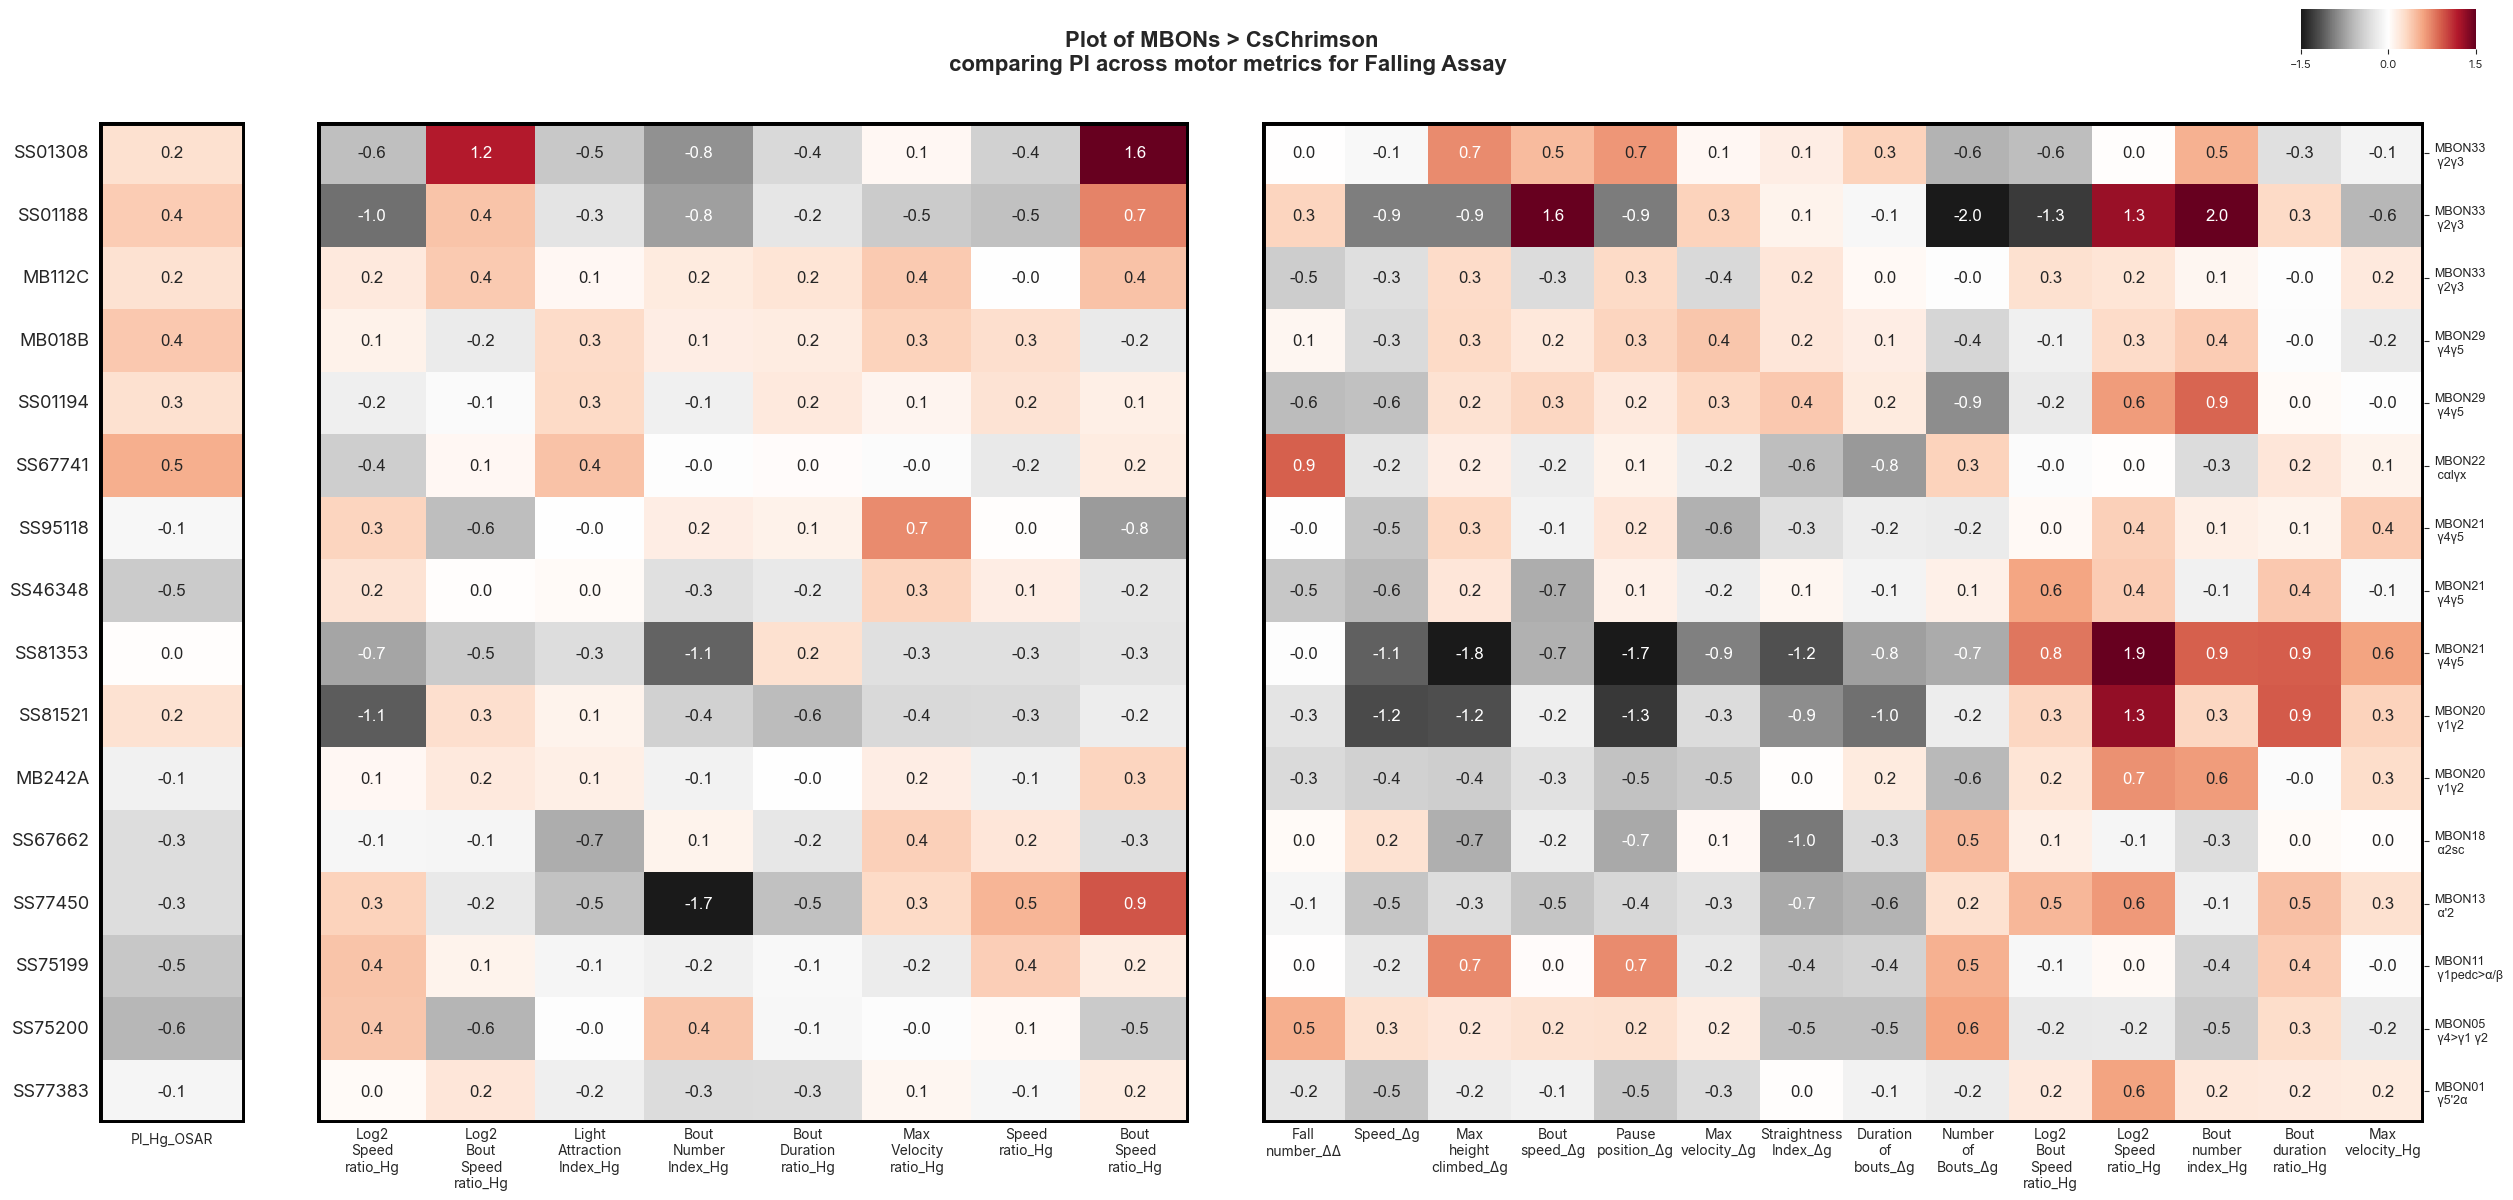

In [68]:
import scipy.stats

plt.rcParams["font.family"] = "Inter"

responder = "Chrimson2"


# Read the specific condition file
totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar climbing\\Totalcomparisonofallmetrics-Full.xlsx")

if responder == 'Chrimson2':
    responderrename = "CsChrimson"
    df_linereg = totalmetriccomparison[totalmetriccomparison['responder']=="Chrimson2"].reset_index(drop=True)
    colormap = 'RdGy_r'

if responder == 'ACR':
    responderrename = "GtACR1"
    df_linereg = totalmetriccomparison[totalmetriccomparison['responder']=="ACR"].reset_index(drop=True)
    colormap = 'BrBG'

totalmapplots = df_linereg.drop(columns = ['genotypeandresponder', 'responder'])
df_totalmetrics_origin = totalmapplots[totalmapplots['MBON'].isin(singlecellmbon)]

## if i want specific mbons else skip
# mbons_of_interest = ['MB018B']
# df_totalmetrics_origin = totalmapplots[totalmapplots['MBON'].isin(mbons_of_interest)]
# df_totalmetrics = df_totalmetrics_origin.set_index(['MBON'])

# df_totalmetrics_origin = totalmapplots.copy()
df_totalmetrics = df_totalmetrics_origin.set_index(['MBON'])

#adding extra axes label
lobloclst = []
mbonloclst = []
df_singleresponder_lobeloc = df_totalmetrics.copy()

for n in df_totalmetrics_origin['MBON']:    
    lobloclst.append(lobelocation[lobelocation['MBON'] == n]['Lobe_location'].values[0])
    mbonloclst.append(lobelocation[lobelocation['MBON'] == n]['MBON number'].values[0])
df_singleresponder_lobeloc['Lobe'] = lobloclst
df_singleresponder_lobeloc['Name'] = mbonloclst

# Sort by MBON numbers instead of bspeed_deltag
df_singleresponder_lobeloc = df_singleresponder_lobeloc.sort_values(by = "Name", ascending=True)

# Separate data for three subplots
# Subplot 1: Only PI data
df60_PIonly = df_singleresponder_lobeloc[['PI_Hg_OSAR']].copy()

# Subplot 2: for anything with _OSAR (excluding PI)
df60_osaronly = df_singleresponder_lobeloc.filter(regex='_OSAR$').drop(columns=['PI_Hg_OSAR']).copy()

# Subplot 3: for anything with _Climbing 
df60_climbingonly = df_singleresponder_lobeloc.filter(regex='_Climbing$').copy()

# Create figure with 3 subplots
fig1, (ax4_left, ax4_middle, ax4_right) = plt.subplots(1, 3, figsize=(30, 13), gridspec_kw={'width_ratios': [1, 6, 8], 'wspace': 0.1})

newdf_singleresponder_lobeloc = pd.DataFrame()
naming = df_singleresponder_lobeloc['Name'].to_frame().rename(columns = {"Name": ""})
lobing = df_singleresponder_lobeloc['Lobe'].to_frame().rename(columns = {"Lobe": ""})
newlabel =(naming.values + "\n " + lobing.values).tolist()
newdf_singleresponder_lobeloc['Merge'] = newlabel

# Labels for subplot 1 (PI only)
xticklabel_subplot1 = ['PI_Hg_OSAR']

# Labels for subplot 2 (OSAR only)
xticklabellist_osar = [a.replace("_OSAR", " ") for a in df60_osaronly.columns.tolist()]

# Labels for subplot 3 (Climbing only)
xticklabellist_climbing = [a.replace("_Climbing", " ") for a in df60_climbingonly.columns.tolist()]

# Colorbar for subplot 3 (rightmost)
cax2 = inset_axes(ax4_right,
                 width="15%",  # width: 40% of parent_bbox width
                 height="4%",  # height: 10% of parent_bbox height
                 loc='lower right',
                 bbox_to_anchor=(0.02, 1.1, 1, 1),
                 bbox_transform=ax4_right.transAxes,
                 borderpad=-2,
                 )

sns.set_style("whitegrid", {'axes.grid' : False})    

# Subplot 1: PI only (left) - with MBON names as y-labels       
j7_left = sns.heatmap(df60_PIonly, ax=ax4_left, annot=True, fmt=".1f", vmin=-1.5, vmax=1.5, cmap=colormap, 
                     annot_kws={"size": 12}, linewidths=0.0, edgecolor="none", 
                     xticklabels=xticklabel_subplot1, yticklabels=True, clip_on=False, cbar=False)

# Subplot 2: OSAR only (middle) - no y-labels
j7_middle = sns.heatmap(df60_osaronly, ax=ax4_middle, annot=True, fmt=".1f", vmin=-1.5, vmax=1.5, cmap=colormap, 
                       annot_kws={"size": 12}, linewidths=0.0, edgecolor="none", 
                       xticklabels=xticklabellist_osar, yticklabels=False, clip_on=False, cbar=False)

# Subplot 3: Climbing only (right) - no y-labels on left side, colorbar
j7_right = sns.heatmap(df60_climbingonly, ax=ax4_right, annot=True, fmt=".1f", vmin=-1.5, vmax=1.5, cmap=colormap, 
                      linewidths=0.0, edgecolor="none", xticklabels=xticklabellist_climbing, yticklabels=False,
                      clip_on=False, cbar_ax=cax2, cbar_kws=dict(orientation="horizontal", ticks=[-1.5, 0, 1.5]), 
                      annot_kws={"size": 12})

# Colorbar changes
cbar = j7_right.collections[0].colorbar
cbar.ax.tick_params(labelsize=8)

# For more detailed control (optional):
for label in cbar.ax.get_xticklabels():  # Note: use get_xticklabels() for horizontal colorbar
    label.set_family('Inter')

# Format subplot 1 (left - with j7_left y-labels)
j7_left.set_ylabel('')
j7_left.set_yticklabels(j7_left.get_yticklabels(), va='center', rotation=0, fontsize=13)
j7_left.set_xticklabels(j7_left.get_xticklabels(), fontsize=10)

# Format subplot 2 (middle - no y-labels)
j7_middle.set_ylabel('')
j7_middle.set_xticklabels(j7_middle.get_xticklabels(), fontsize=10)
NLProcessing.wrap_labels(j7_middle, 2)
j7_middle.tick_params(axis='both', which='both', length=0)

# Format subplot 3 (right)
j7_right.set_ylabel('')
j7_right.set_xticklabels(j7_right.get_xticklabels(), fontsize=10)
NLProcessing.wrap_labels(j7_right, 2)
j7_right.tick_params(axis='both', which='both', length=0)

# Drawing frames for all subplots
# Frame for subplot 1
j7_left.axhline(y=0, color='k', linewidth=5) 
j7_left.axhline(y=len(df60_PIonly), color='k', linewidth=5) 
j7_left.axvline(x=0, color='k', linewidth=5) 
j7_left.axvline(x=1, color='k', linewidth=5) 

# Frame for subplot 2
j7_middle.axhline(y=0, color='k', linewidth=5) 
j7_middle.axhline(y=len(df60_osaronly), color='k', linewidth=5) 
j7_middle.axvline(x=0, color='k', linewidth=5) 
j7_middle.axvline(x=len(df60_osaronly.columns), color='k', linewidth=5) 

# Frame for subplot 3
j7_right.axhline(y=0, color='k', linewidth=5) 
j7_right.axhline(y=len(df60_climbingonly), color='k', linewidth=5) 
j7_right.axvline(x=0, color='k', linewidth=5) 
j7_right.axvline(x=len(df60_climbingonly.columns), color='k', linewidth=5) 

# Secondary axes for subplot 3 - MBON lobe and naming labels on right side (j8_right)
j8_right = j7_right.twinx()
j8_right.set_ylim(j7_right.get_ylim())

# Y labels for MBON lobes and naming on subplot 3 (right side)
labellinglist = newdf_singleresponder_lobeloc['Merge'].iloc[::-1]
labelledlist = []
for n in labellinglist:
    labelledlist.extend(n)

# Set ticks to match the data positions
tick_positions = [i + 0.5 for i in range(len(df60_climbingonly))]
j8_right.set_yticks(tick_positions)
j8_right.set_yticklabels(labelledlist, fontsize=9)
j8_right.spines['top'].set_visible(False)
j8_right.spines['right'].set_visible(False)
j8_right.spines['bottom'].set_visible(False)
j8_right.spines['left'].set_visible(False)

# Overall title
fig1.suptitle('Plot of MBONs > ' + responderrename +' \n comparing PI across motor metrics for Climbing Assay', x=0.5, y=0.95, weight='bold', fontsize=16)
plt.rcParams["font.family"] = "Inter"
fig1.tight_layout()

# plt.savefig(openPath + "images\\" + date + "_" + responder + "_deltagheatmapwithlobelocations.png", dpi = 1200)
#plt.savefig(filesavedir + date + "_" + responder + "comparing PI against motor_hedgesgheatmap_2.svg")

In [ ]:
metriccolumns = ['Fall number_ΔΔ_Climbing', 'Speed_Δg_Climbing',
       'Max height climbed_Δg_Climbing', 'Bout speed_Δg_Climbing',
       'Pause position_Δg_Climbing', 'Max velocity_Δg_Climbing',
       'Straightness Index_Δg_Climbing', 'Duration of bouts_Δg_Climbing',
       'Number of Bouts_Δg_Climbing', 'MBON',
       
       'PI_Hg_OSAR', 'Log2 Speed ratio_Hg_OSAR',
       'Log2 Bout Speed ratio_Hg_OSAR', 'Light Attraction Index_Hg_OSAR',
       'Bout Number Index_Hg_OSAR', 'Bout Duration ratio_Hg_OSAR',
       'Max Velocity ratio_Hg_OSAR']



climbingonly_cols = [n for n in metriccolumns if n.endswith('Climbing')]
osaronly_cols = [n for n in metriccolumns if n.endswith('OSAR')]

df_nt_metricreduce = df_totalmetrics_origin[metriccolumns]
df_climbingcol = pd.concat([df_totalmetrics_origin[climbingonly_cols],df_totalmetrics_origin['MBON']], axis =1)
df_osarcol = pd.concat([df_totalmetrics_origin[osaronly_cols],df_totalmetrics_origin['MBON']], axis =1)

NameError: name 'df_totalmetrics_origin' is not defined

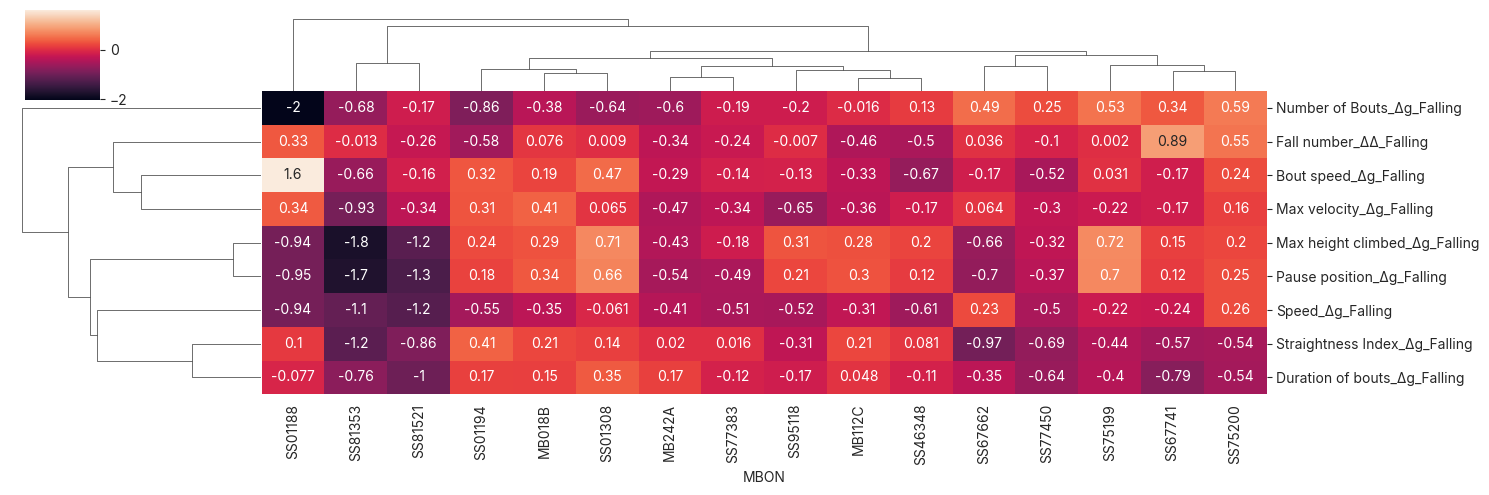

In [ ]:
df_transpose = df_climbingcol.set_index('MBON').transpose()

df_heatmapcluster = sns.clustermap(df_transpose, annot=True, figsize=(15,5))
#plt.setp(df_heatmapcluster.ax_heatmap.get_xticklabels(), va='center', rotation=0, fontsize=8)

## Heatmap showing vertical vs horizontal diff

In [5]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

responder = "Chrimson2"
mbons_of_no_interest = ["R76B09"]

plt.rcParams["font.family"] = "Inter"

totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar climbing\\Totalcomparisonofallmetrics-Full.xlsx")

osarmatchdf = totalmetriccomparison.copy()

if responder == 'Chrimson2':
    responderrename = "CsChrimson"
    df_specificmbon = osarmatchdf[osarmatchdf['responder']=="Chrimson2"].reset_index(drop=True)
    colormap = 'RdGy'

if responder == 'ACR':
    responderrename = "GtACR1"
    df_specificmbon = osarmatchdf[osarmatchdf['responder']=="ACR"].reset_index(drop=True)
    colormap = 'BrBG'

df_totalmetrics_origin = df_specificmbon[~df_specificmbon['MBON'].isin(mbons_of_no_interest)]
df_totalmetrics = df_totalmetrics_origin.set_index(['MBON'])
df00 = df_specificmbon.set_index(['genotypeandresponder'])

#adding extra axes label
lobloclst = []
mbonloclst = []
df_singleresponder_lobeloc = df_totalmetrics.copy()

for n in df_totalmetrics_origin['MBON']:    
    lobloclst.append(lobelocation[lobelocation['MBON'] == n]['Lobe_location'].values[0])
    mbonloclst.append(lobelocation[lobelocation['MBON'] == n]['MBON number'].values[0])
df_singleresponder_lobeloc['Lobe'] = lobloclst
df_singleresponder_lobeloc['Name'] = mbonloclst

# Sort by MBON numbers instead of bspeed_deltag
df_singleresponder_lobeloc = df_singleresponder_lobeloc.sort_values(by = "Name", ascending=True)

# Separate data for two subplots
# Subplot 1: Only fallnumber (Delta-delta)
df60_fallnumber = df_singleresponder_lobeloc[['Log2 Speed ratio_Δg_OSAR', 'Log2 Bout Speed ratio_Δg_OSAR']].copy()

# Subplot 2: All other columns (Delta-g) 
df60_other = df_singleresponder_lobeloc.drop(['Name', 'Lobe', 'Log2 Speed ratio_Δg_OSAR', 'Log2 Bout Speed ratio_Δg_OSAR','PI_Δg_OSAR', 'genotypeandresponder', 'responder',
       'Light Attraction Index_Δg_OSAR'], axis = 1).copy() 

# Create figure with 2 subplots
fig1, (ax4_left, ax4_right) = plt.subplots(1, 2, figsize=(15, 3), gridspec_kw={'width_ratios': [1, 9]})

newdf_singleresponder_lobeloc = pd.DataFrame()
naming = df_singleresponder_lobeloc['Name'].to_frame().rename(columns = {"Name": ""})
lobing = df_singleresponder_lobeloc['Lobe'].to_frame().rename(columns = {"Lobe": ""})
newlabel =(naming.values + "\n " + lobing.values).tolist()
newdf_singleresponder_lobeloc['Merge'] = newlabel

# Labels for subplot 1 (fallnumber)
xticklabel_fallnumber = ['Log2 Speed ratio', 'Log2 Bout Speed ratio']

# Labels for subplot 2 (other columns)
# xticklabellist_other = df60_other.columns.tolist()
xticklabellist_other = [a.replace("_Δg_Climbing", " ") for a in df60_other.columns.tolist()]

#colorbar for subplot 2
cax2 = inset_axes(ax4_right,
                 width="15%",  # width: 40% of parent_bbox width
                 height="8%",  # height: 10% of parent_bbox height
                 loc='lower right',
                 bbox_to_anchor=(0.02, 1.5, 1, 1),
                 bbox_transform=ax4_right.transAxes,
                 borderpad=-2,
                 )

sns.set_style("whitegrid", {'axes.grid' : False})    

# Subplot 1: fallnumber (Delta-delta) - now with MBON names as y-labels       
j7_left = sns.heatmap(df60_fallnumber, ax = ax4_left, annot=True, fmt=".1f", vmin = -1.5, vmax = 1.5, cmap=colormap, annot_kws={"size": 12, }, linewidths=0.0, edgecolor = "none",  xticklabels=xticklabel_fallnumber, yticklabels=True,
                 clip_on=False, cbar = False)

# Subplot 2: other columns (Delta-g) - no y-labels on left side
j7_right = sns.heatmap(df60_other, ax = ax4_right, annot=True, fmt=".1f", vmin = -1.5, vmax = 1.5, cmap=colormap, linewidths=0.0, edgecolor = "none",  xticklabels=xticklabellist_other, yticklabels=True,
                 clip_on=False, cbar_ax=cax2, cbar_kws = dict(orientation = "horizontal", ticks = [-1.5,0,1.5]), annot_kws={"size": 12, })

# colorbar changes
cbar = j7_right.collections[0].colorbar
cbar.ax.tick_params(labelsize=8)

# For more detailed control (optional):
for label in cbar.ax.get_xticklabels():  # Note: use get_xticklabels() for horizontal colorbar
    # label.set_fontsize(10)
    label.set_family('Inter')

    
# Format subplot 1
j7_left.set_ylabel('')
j7_left.set_yticklabels(j7_left.get_yticklabels(), va='center', rotation = 0, fontsize = 13)
j7_left.set_xticklabels(j7_left.get_xticklabels(),  rotation = 0,fontsize = 10)
j7_left.set_title('OSAR', fontsize = 14)
NLProcessing.wrap_labels(j7_left, 2)

# Format subplot 2
j7_right.set_ylabel('')
j7_right.set_yticklabels([], visible = False)
j7_right.set_xticklabels(j7_right.get_xticklabels(), fontsize = 10)
NLProcessing.wrap_labels(j7_right, 2)
j7_right.set_title('Climbing',fontsize = 14)
j7_right.tick_params(axis='both', which='both', length=0)

# Drawing the frame for subplot 1
j7_left.axhline(y = 0, color = 'k', linewidth = 5) 
j7_left.axhline(y = len(df60_fallnumber), color = 'k', linewidth = 5) 
j7_left.axvline(x = 0, color = 'k', linewidth = 5) 
j7_left.axvline(x = 2, color = 'k', linewidth = 5) 

# Drawing the frame for subplot 2
j7_right.axhline(y = 0, color = 'k', linewidth = 5) 
j7_right.axhline(y = len(df60_other), color = 'k', linewidth = 5) 
j7_right.axvline(x = 0, color = 'k', linewidth = 5) 
j7_right.axvline(x = len(df60_other.columns), color = 'k', linewidth = 5) 

#secondary axes for subplot 2 - MBON lobe and naming labels on right side
j8_right = j7_right.twinx()
j8_right.set_ylim([0,j7_right.get_ylim()[0]])
j8_right.set_yticks(j7_right.get_yticks())

#y labels for mbon lobes and naming on subplot 2 (right side)
labellinglist = newdf_singleresponder_lobeloc['Merge'].iloc[::-1]
labelledlist = []
for n in labellinglist:
    labelledlist.extend(n)
j8_right.set_yticklabels(labelledlist, fontsize=9)
j8_right.spines['top'].set_visible(False)
j8_right.spines['right'].set_visible(False)
j8_right.spines['bottom'].set_visible(False)
j8_right.spines['left'].set_visible(False)

fig1.suptitle(f"Plot of MBONs > {responderrename} Hedges'g across\n vertical vs horizontal motor differences", 
                x=0.5, weight='bold', fontsize=14)

fig1.tight_layout()

#plt.savefig(filesavedir + date + "_" + responder + "_hedgesgheatmap_horizontal vs vertical.png", dpi=1200)
#plt.savefig(filesavedir + date + "_" + responder + "_hedgesgheatmap_horizontal vs vertical.svg")

plt.show()


NameError: name 'lobelocation' is not defined

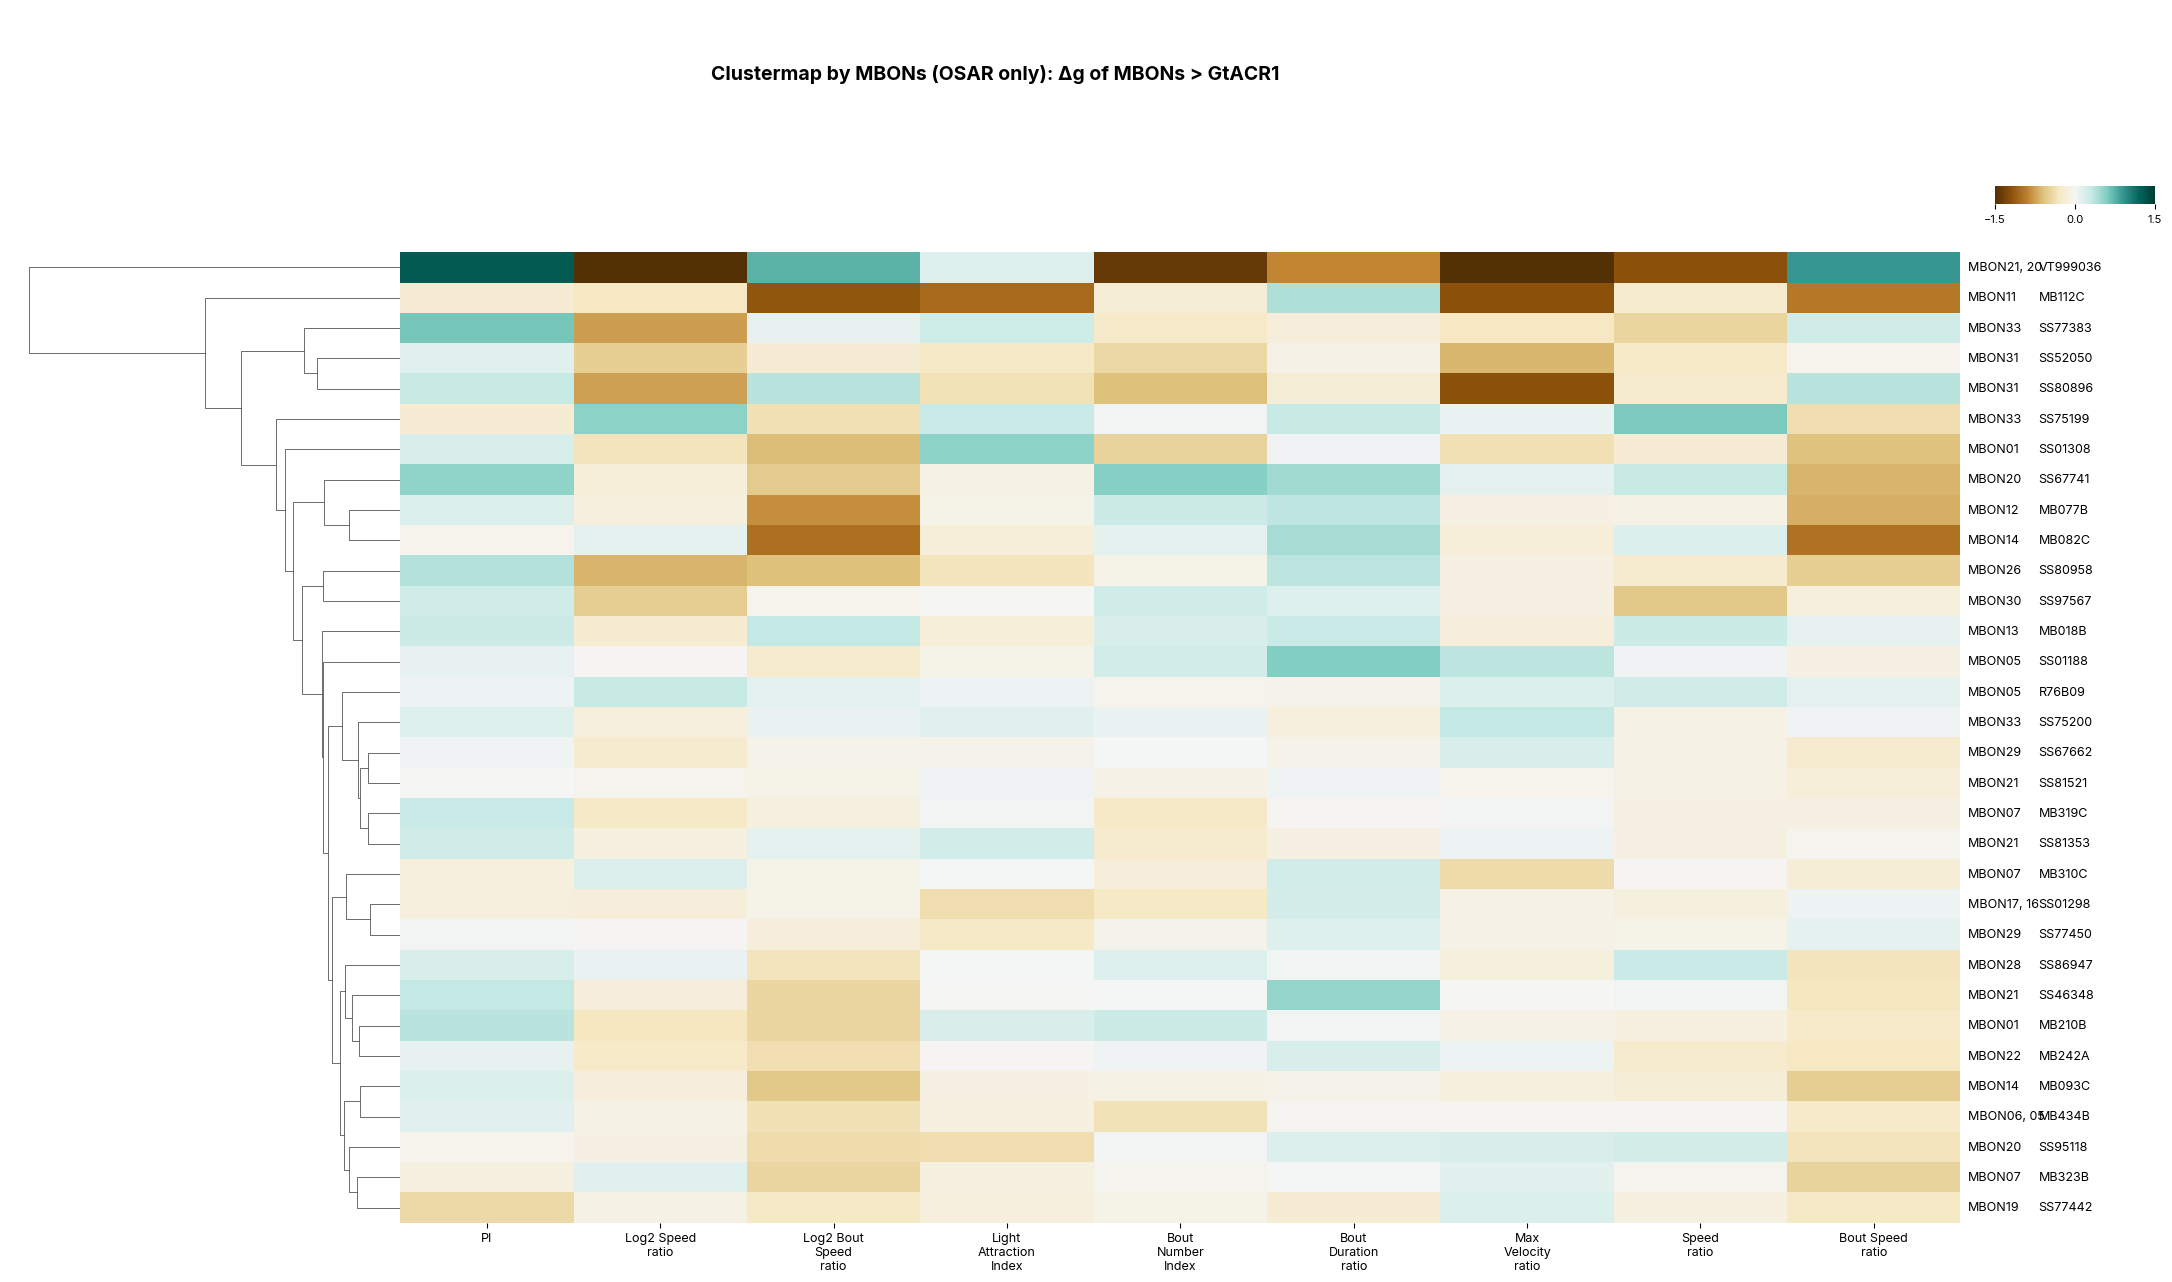

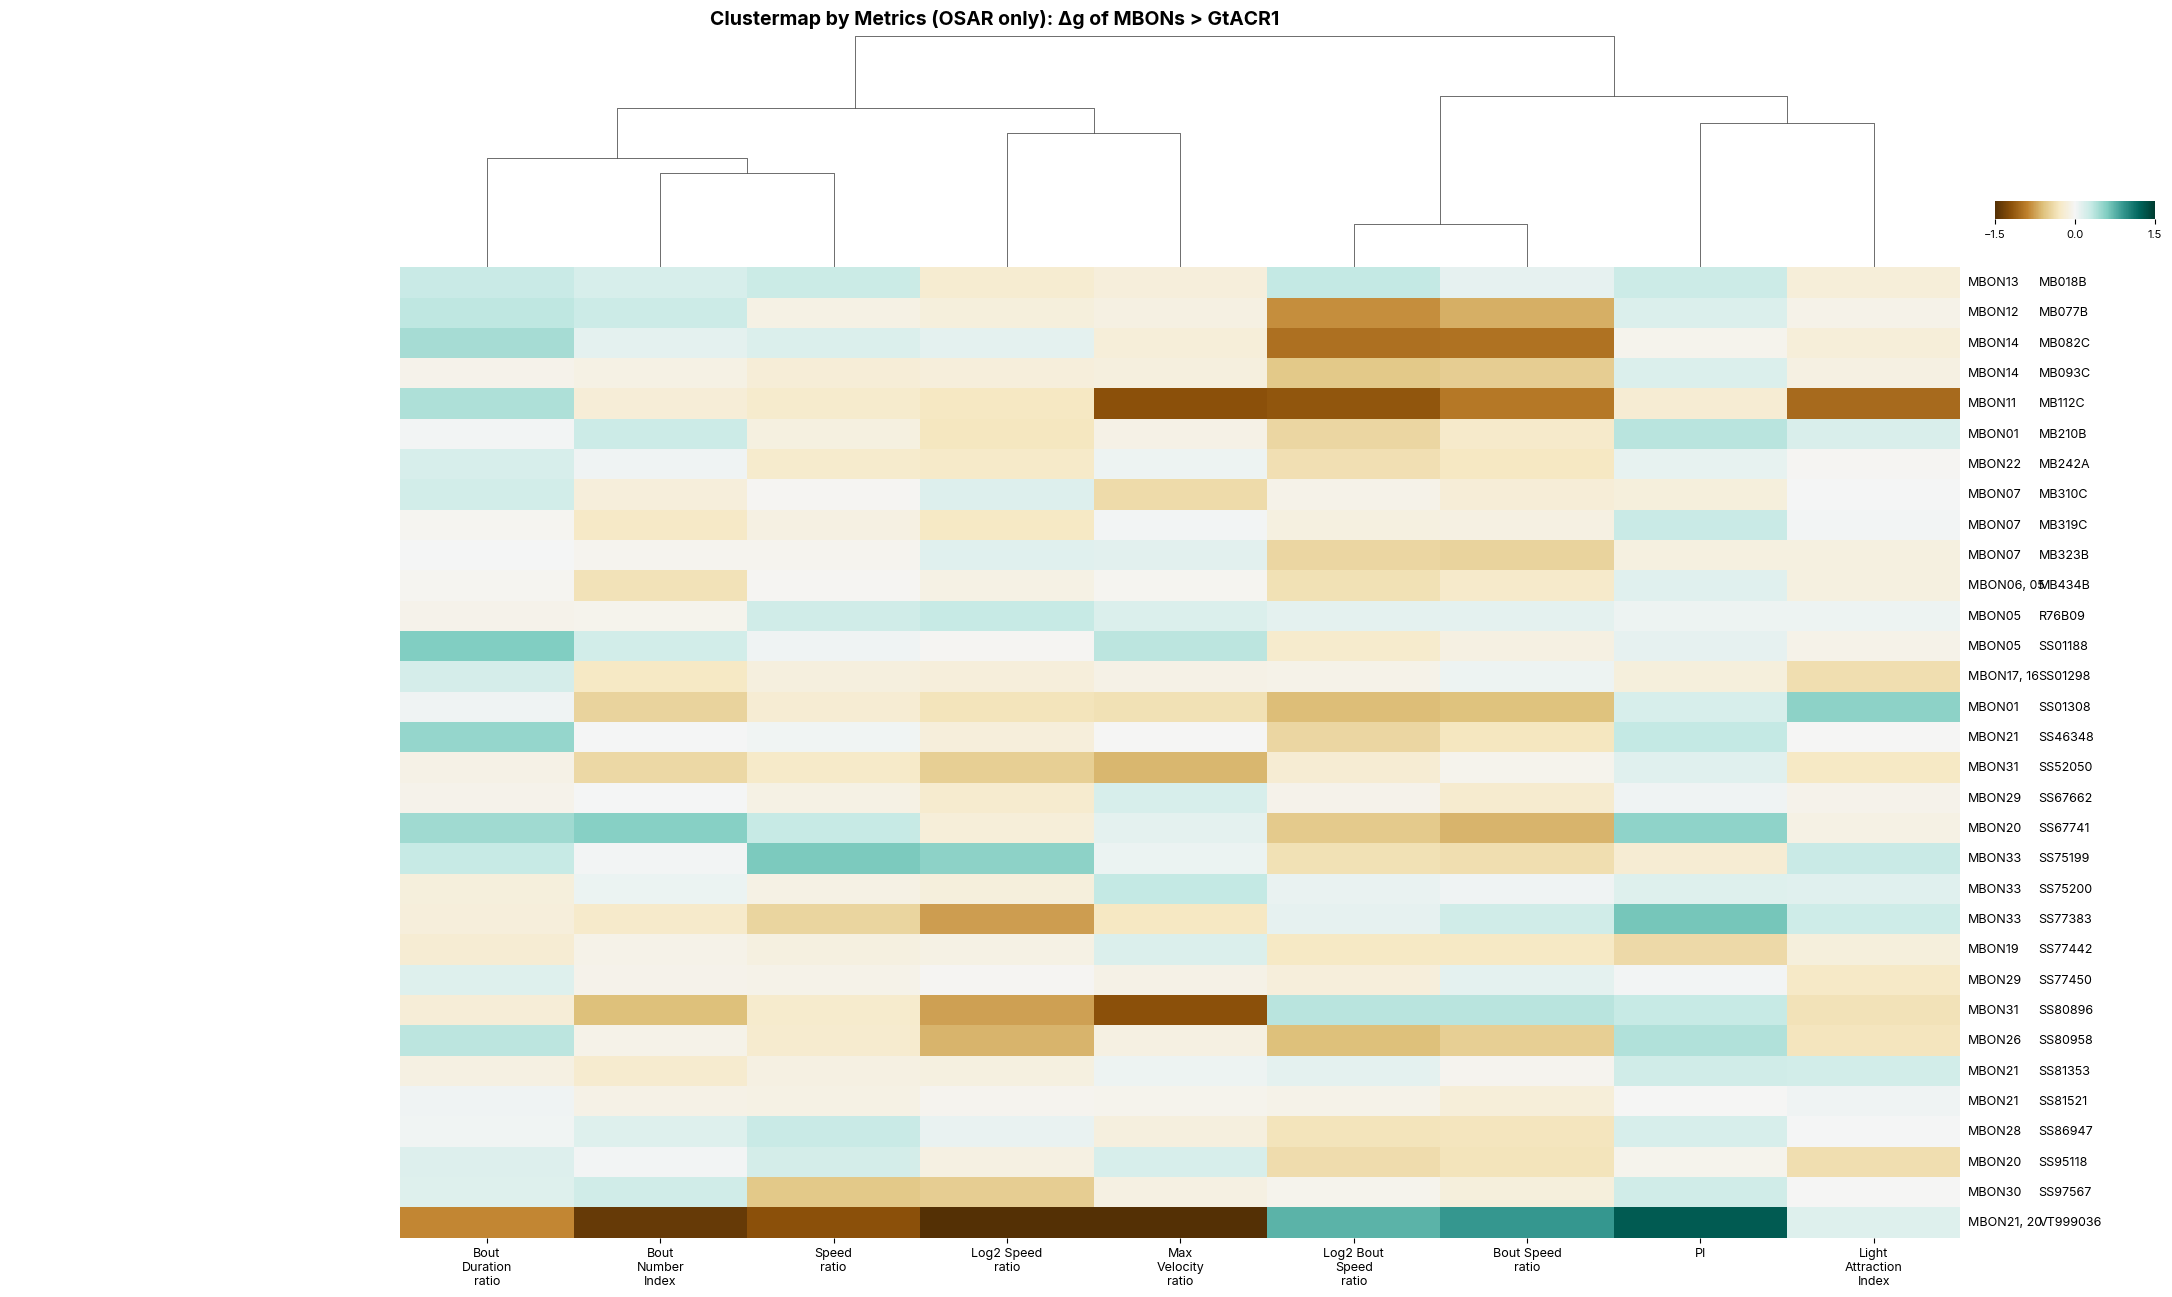

In [10]:
responder = "ACR"
data_mode = "OSAR"

totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar climbing\\Totalcomparisonofallmetrics-Full.xlsx")

if responder == 'Chrimson2':
    responderrename = "CsChrimson"
    df_cluster = totalmetriccomparison[totalmetriccomparison['responder']=="Chrimson2"].reset_index(drop=True)
    colormap = 'RdGy'
elif responder == 'ACR':
    responderrename = "GtACR1"
    df_cluster = totalmetriccomparison[totalmetriccomparison['responder']=="ACR"].reset_index(drop=True)
    colormap = 'BrBG'

lobloclst, mbonloclst = [], []
for n in df_cluster['MBON']:
    lobloclst.append(lobelocation[lobelocation['MBON'] == n]['Lobe_location'].values[0])
    mbonloclst.append(lobelocation[lobelocation['MBON'] == n]['MBON number'].values[0])
df_cluster['Lobe'] = lobloclst
df_cluster['Name'] = mbonloclst

df_cluster_data = df_cluster.drop(columns=['genotypeandresponder', 'responder', 'Lobe', 'Name', 'MBON']).copy()
df_cluster_data.index = df_cluster['MBON']

if data_mode == "OSAR":
    df_cluster_data = df_cluster_data.filter(regex='_OSAR$')
    mode_label = "OSAR only"
elif data_mode == "Climbing":
    df_cluster_data = df_cluster_data.filter(regex='_Climbing$')
    mode_label = "Climbing only"
else:
    mode_label = "OSAR + Climbing"

df_cluster['Name_short'] = df_cluster['Name']
xticklabellist = [c.replace("_Hg_OSAR", "").replace("_Δg_OSAR", "").replace("_Δg_Climbing", "").replace("_ΔΔ_Climbing", "") for c in df_cluster_data.columns]

plt.rcParams["font.family"] = "Inter"

dash_connector = " ———— "  # Multiple dashes to fill the gap
x_pos_name = 1.005
x_pos_mbon = 1.005 + 0.045
x_pos_lobe = 1.005 + 0.090

g1 = sns.clustermap(df_cluster_data, cmap=colormap, method='weighted', metric='euclidean', 
                    yticklabels=False, xticklabels=xticklabellist, vmin=-1.5, vmax=1.5,
                    row_cluster=True, col_cluster=False, annot=False,
                    cbar_kws=dict(orientation='horizontal', ticks=[-1.5, 0, 1.5]), 
                    figsize=(20, 14), cbar_pos=(1.00, 0.85, 0.08, 0.013))

g1.ax_cbar.tick_params(labelsize=8)

g1.ax_heatmap.set_ylabel('')
g1.ax_heatmap.set_xticklabels(g1.ax_heatmap.get_xticklabels(), rotation=0, fontsize=9)
NLProcessing.wrap_labels(g1.ax_heatmap, 10)
g1.fig.suptitle(f'Clustermap by MBONs ({mode_label}): Δg of MBONs > {responderrename}', weight='bold', fontsize=14, y=0.95)

ax_heatmap = g1.ax_heatmap
row_order = g1.dendrogram_row.reordered_ind

for i, idx in enumerate(row_order):
    y_pos = i + 0.5
    ax_heatmap.text(x_pos_name, y_pos, df_cluster['Name_short'].iloc[idx] , ha='left', va='center', fontsize=9, transform=ax_heatmap.get_yaxis_transform())
    ax_heatmap.text(x_pos_mbon, y_pos, df_cluster['MBON'].iloc[idx], ha='left', va='center', fontsize=9, transform=ax_heatmap.get_yaxis_transform())
    #ax_heatmap.text(x_pos_lobe, y_pos, df_cluster['Lobe'].iloc[idx], ha='left', va='center', fontsize=9, transform=ax_heatmap.get_yaxis_transform())

g2 = sns.clustermap(df_cluster_data, cmap=colormap, method='weighted', metric='euclidean', 
                    yticklabels=False, xticklabels=xticklabellist, vmin=-1.5, vmax=1.5,
                    row_cluster=False, col_cluster=True, annot=False,
                    cbar_kws=dict(orientation='horizontal', ticks=[-1.5, 0, 1.5]), 
                    figsize=(20, 14), cbar_pos=(1.00, 0.85, 0.08, 0.013))

g2.ax_cbar.tick_params(labelsize=8)

g2.ax_heatmap.set_ylabel('')
g2.ax_heatmap.set_xticklabels(g2.ax_heatmap.get_xticklabels(), rotation=0, fontsize=9)
NLProcessing.wrap_labels(g2.ax_heatmap, 10)
g2.fig.suptitle(f'Clustermap by Metrics ({mode_label}): Δg of MBONs > {responderrename}', weight='bold', fontsize=14, y = 1.0)

ax_heatmap2 = g2.ax_heatmap
for i in range(len(df_cluster)):
    y_pos = i + 0.5
    ax_heatmap2.text(x_pos_name, y_pos, df_cluster['Name_short'].iloc[i] , ha='left', va='center', fontsize=9, transform=ax_heatmap2.get_yaxis_transform())
    ax_heatmap2.text(x_pos_mbon, y_pos, df_cluster['MBON'].iloc[i] , ha='left', va='center', fontsize=9, transform=ax_heatmap2.get_yaxis_transform())
    #ax_heatmap2.text(x_pos_lobe, y_pos, df_cluster['Lobe'].iloc[i], ha='left', va='center', fontsize=9, transform=ax_heatmap2.get_yaxis_transform())

plt.show()
# g1.savefig(filesavedir + date + "_clustermap_MBON_" + responder + "_" + data_mode + "_.png", dpi=1200)
# g2.savefig(filesavedir + date + "_clustermap_metric_" + responder + "_" + data_mode + "_.png", dpi=1200)

## Climbing

In [30]:
responder = "Chrimson2"
data_mode = "Climbing"

totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar climbing\\Climbing_" + filedate + ".xlsx")

if responder == 'Chrimson2':
    responderrename = "CsChrimson"
    df_cluster = totalmetriccomparison[totalmetriccomparison['responder']=="Chrimson2"].reset_index(drop=True)
    colormap = 'coolwarm'
elif responder == 'ACR':
    responderrename = "GtACR1"
    df_cluster = totalmetriccomparison[totalmetriccomparison['responder']=="ACR"].reset_index(drop=True)
    colormap = 'coolwarm'

# Add lobe and name info
for n in df_cluster['MBON']:
    df_cluster.loc[df_cluster['MBON'] == n, 'Lobe'] = lobelocation[lobelocation['MBON'] == n]['Lobe_location'].values[0]
    df_cluster.loc[df_cluster['MBON'] == n, 'Name'] = lobelocation[lobelocation['MBON'] == n]['MBON number'].values[0]

df_cluster_data = df_cluster.drop(columns=['genotypeandresponder', 'responder', 'Lobe', 'Name', 'MBON']).copy()
df_cluster_data.index = df_cluster['MBON']

df_cluster['Name_short'] = df_cluster['Name']
df_cluster['Lobes_parsed'] = df_cluster['Lobe'].apply(NLProcessing.parse_lobes)

# Palettes
lobe_palette = {'α': '#E69F00', "α'": '#F0E442', 'β': '#009E73', "β'": '#CC79A7', 'γ': '#999999', 'Calyx': '#000000', 'Unknown': '#FFFFFF'}
col_colors = ['#117733' if 'OSAR' in c else '#AA4499' for c in df_cluster_data.columns]

# Settings
fig_width, fig_height = 8, 15
dendrogram_size = 0.08
gap = 0.008  # Gap between elements

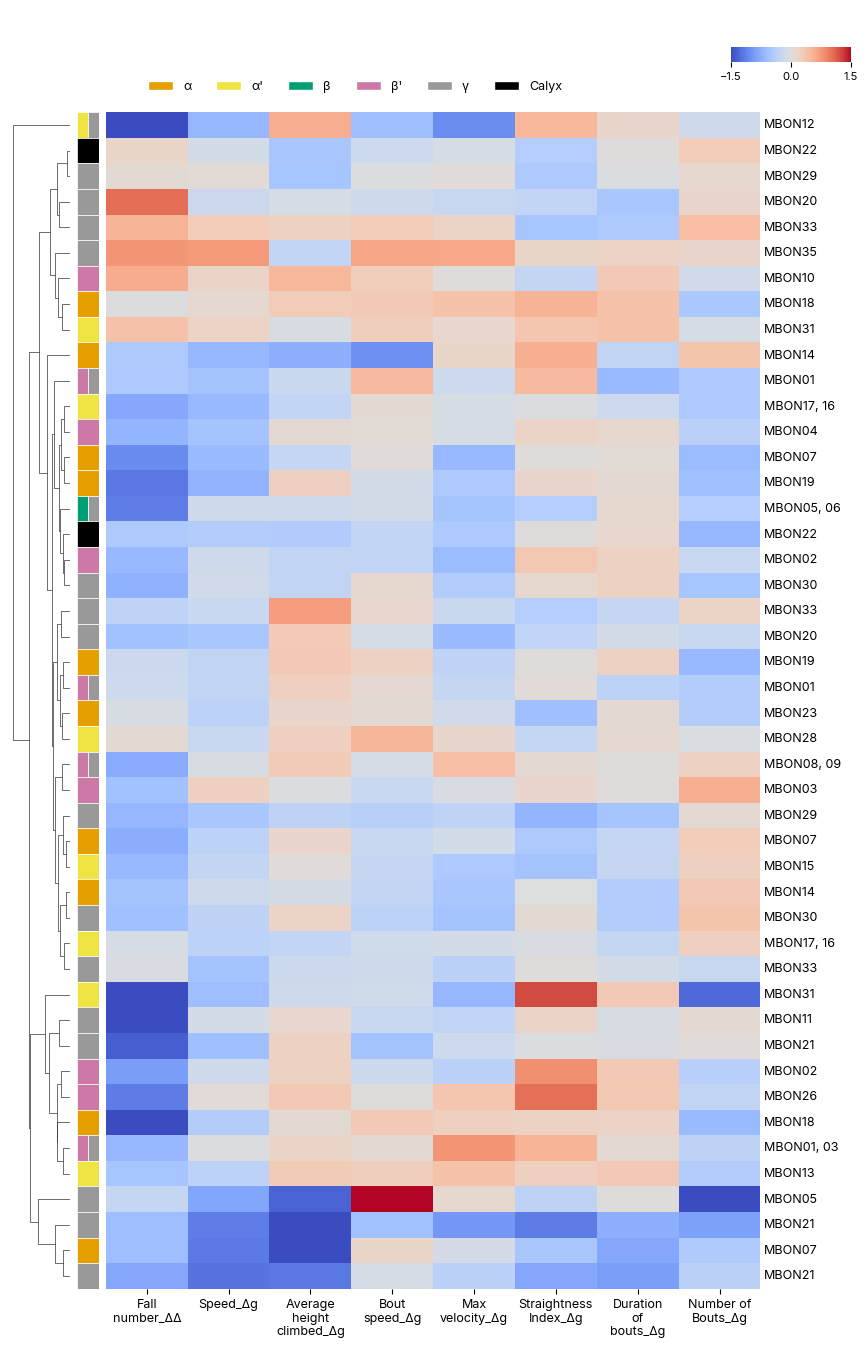

In [31]:
# Clustermap by MBONs (row clustering)
plt.rcParams["font.family"] = "Inter"

exclude = ['pause position', 'log2 bout speed', 'log2 speed ratio', 'bout number index', 'bout duration ratio', 'max velocity ratio']
df_clusternew = df_cluster_data[[c for c in df_cluster_data.columns if not any(e in c.lower() for e in exclude)]]

g1 = sns.clustermap(df_clusternew, cmap=colormap, method='complete', metric='euclidean',
                    yticklabels=False, xticklabels=[col.replace("_Δg_Climbing", "").replace("_ΔΔ_Climbing", "") for col in df_clusternew.columns], vmin=-1.5, vmax=1.5,
                    row_cluster=True, col_cluster=False, annot=False,
                    row_colors=['#FFFFFF'] * len(df_clusternew),
                    dendrogram_ratio=(dendrogram_size, dendrogram_size),
                    cbar_kws=dict(orientation='horizontal', ticks=[-1.5, 0, 1.5]),
                    figsize=(fig_width, fig_height), cbar_pos=(0.92, 0.955, 0.15, 0.010))


cbar = g1.ax_cbar
cbar.tick_params(labelsize=8)


row_colors_pos = g1.ax_row_colors.get_position()
heatmap_pos = g1.ax_heatmap.get_position()


g1.ax_row_colors.set_position([row_colors_pos.x0 + gap, row_colors_pos.y0, row_colors_pos.width, row_colors_pos.height])
g1.ax_heatmap.set_position([heatmap_pos.x0 + gap*2, heatmap_pos.y0, heatmap_pos.width - gap*2, heatmap_pos.height])


ax_row_colors = g1.ax_row_colors
row_order = g1.dendrogram_row.reordered_ind
ax_row_colors.clear()
ax_row_colors.set_xlim(0, 1)
ax_row_colors.set_ylim(0, len(row_order))
ax_row_colors.invert_yaxis()
ax_row_colors.axis('off')

for i, idx in enumerate(row_order):
    lobes = df_cluster['Lobes_parsed'].iloc[idx]
    n_lobes = len(lobes) if lobes else 1
    for j, lobe in enumerate(lobes):
        rect = plt.Rectangle((j / n_lobes, i), 1 / n_lobes, 1, facecolor=lobe_palette.get(lobe, '#FFFFFF'), edgecolor='white', linewidth=0.5)
        ax_row_colors.add_patch(rect)


g1.ax_heatmap.set_ylabel('')
g1.ax_heatmap.set_xticklabels(g1.ax_heatmap.get_xticklabels(), ha='center', fontsize=9)
NLProcessing.wrap_labels(g1.ax_heatmap, 10)


for i, idx in enumerate(row_order):
    g1.ax_heatmap.text(1.005, i + 0.5, df_cluster['Name_short'].iloc[idx], ha='left', va='center', fontsize=9, transform=g1.ax_heatmap.get_yaxis_transform())

legend_elements = [plt.Rectangle((0,0),1,1, facecolor=c, edgecolor='white', label=l) for l, c in lobe_palette.items() if l != 'Unknown']
g1.fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.45, 0.95),
              ncol=len(legend_elements), fontsize=9, frameon=False)
mpl.rcParams['svg.fonttype'] = 'none'
plt.savefig("D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\images\\" + date + "_clustermapofmbons_climbing_" + responder + "_" + date + ".svg", bbox_inches="tight")
plt.show()

## OSAR + Climbing clustering

In [81]:
responder = "ACR"
data_mode = "OSAR + Climbing"

totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar climbing\\Totalcomparisonofallmetrics-Full.xlsx")

if responder == 'Chrimson2':
    responderrename = "CsChrimson"
    df_cluster = totalmetriccomparison[totalmetriccomparison['responder']=="Chrimson2"].reset_index(drop=True)
    colormap = 'coolwarm'
elif responder == 'ACR':
    responderrename = "GtACR1"
    df_cluster = totalmetriccomparison[totalmetriccomparison['responder']=="ACR"].reset_index(drop=True)
    colormap = 'coolwarm'

# Add lobe and name info
for n in df_cluster['MBON']:
    df_cluster.loc[df_cluster['MBON'] == n, 'Lobe'] = lobelocation[lobelocation['MBON'] == n]['Lobe_location'].values[0]
    df_cluster.loc[df_cluster['MBON'] == n, 'Name'] = lobelocation[lobelocation['MBON'] == n]['MBON number'].values[0]

df_cluster_data = df_cluster.drop(columns=['genotypeandresponder', 'responder', 'Lobe', 'Name', 'MBON']).copy()
df_cluster_data.index = df_cluster['MBON']

if data_mode == "OSAR":
    df_cluster_data = df_cluster_data.filter(regex='_OSAR$')
    mode_label = "OSAR only"
else:
    mode_label = "OSAR + Climbing"

df_cluster['Name_short'] = df_cluster['Name']
df_cluster['Lobes_parsed'] = df_cluster['Lobe'].apply(NLProcessing.parse_lobes)

# Palettes
lobe_palette = {'α': '#E69F00', "α'": '#F0E442', 'β': '#009E73', "β'": '#CC79A7', 'γ': '#999999', 'Calyx': '#000000', 'Unknown': '#FFFFFF'}
col_colors = ['#117733' if 'OSAR' in c else '#AA4499' for c in df_cluster_data.columns]

# Settings
fig_width, fig_height = 15, 15
dendrogram_size = 0.08
gap = 0.008  # Gap between elements

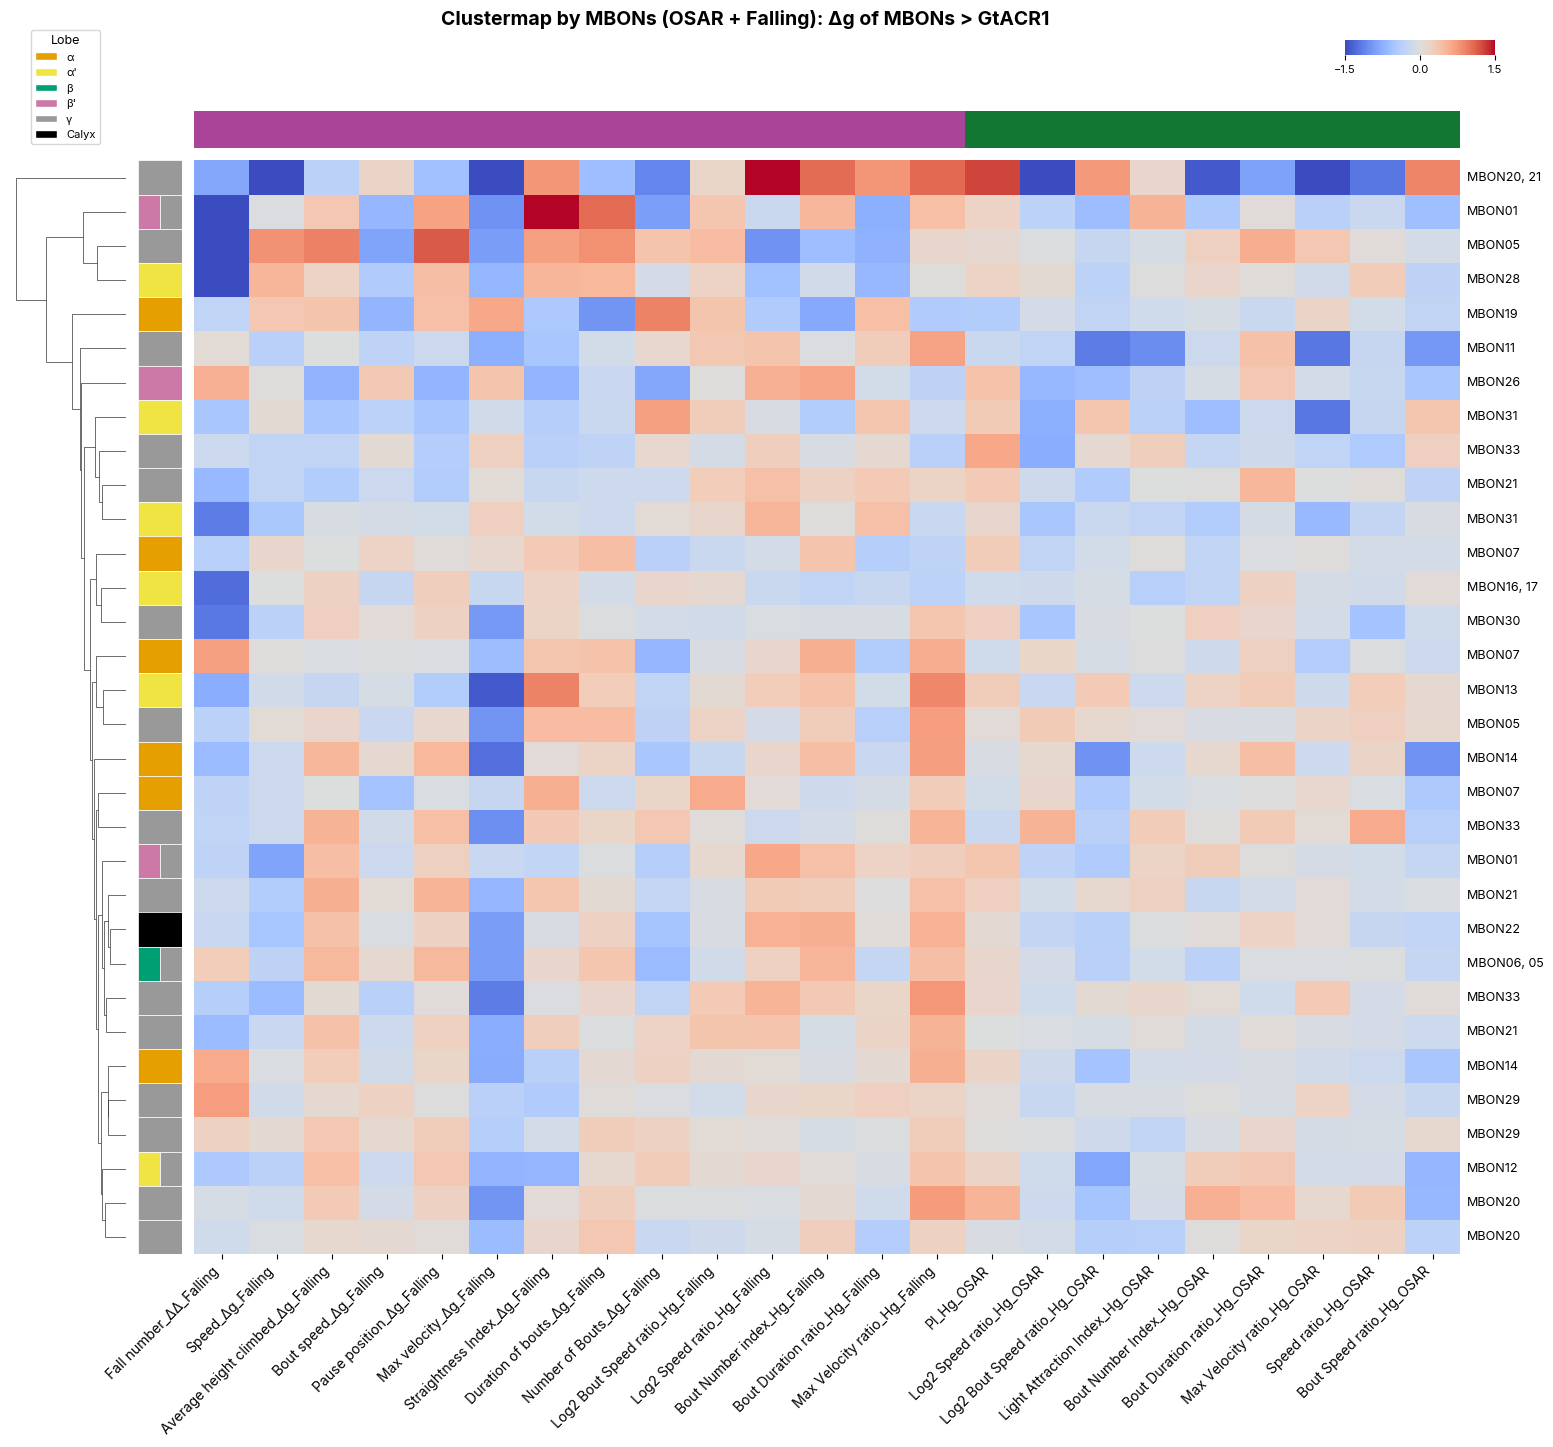

In [82]:
# Clustermap by MBONs (row clustering)
plt.rcParams["font.family"] = "Inter"

g1 = sns.clustermap(df_cluster_data, cmap=colormap, method='weighted', metric='euclidean', 
                    yticklabels=False, xticklabels=list(df_cluster_data.columns), vmin=-1.5, vmax=1.5,
                    row_cluster=True, col_cluster=False, annot=False,
                    row_colors=['#FFFFFF'] * len(df_cluster_data),
                    col_colors=col_colors,
                    dendrogram_ratio=(dendrogram_size, dendrogram_size),
                    cbar_kws=dict(orientation='horizontal', ticks=[-1.5, 0, 1.5]), 
                    figsize=(fig_width, fig_height), cbar_pos=(0.9, 0.97, 0.10, 0.01))

# Colorbar tick size
cbar = g1.ax_cbar
cbar.tick_params(labelsize=8)

# Get positions
row_colors_pos = g1.ax_row_colors.get_position()
heatmap_pos = g1.ax_heatmap.get_position()
col_colors_pos = g1.ax_col_colors.get_position()

# Horizontal gaps: shift row_colors and heatmap right
g1.ax_row_colors.set_position([row_colors_pos.x0 + gap, row_colors_pos.y0, row_colors_pos.width, row_colors_pos.height])
g1.ax_heatmap.set_position([heatmap_pos.x0 + gap*2, heatmap_pos.y0, heatmap_pos.width - gap*2, heatmap_pos.height])

# Vertical gaps: shift col_colors up (away from heatmap)
g1.ax_col_colors.set_position([col_colors_pos.x0 + gap*2, col_colors_pos.y0 + gap, col_colors_pos.width - gap*2, col_colors_pos.height])

# Draw proportional lobe colors
ax_row_colors = g1.ax_row_colors
row_order = g1.dendrogram_row.reordered_ind
ax_row_colors.clear()
ax_row_colors.set_xlim(0, 1)
ax_row_colors.set_ylim(0, len(row_order))
ax_row_colors.invert_yaxis()
ax_row_colors.axis('off')

for i, idx in enumerate(row_order):
    lobes = df_cluster['Lobes_parsed'].iloc[idx]
    n_lobes = len(lobes) if lobes else 1
    for j, lobe in enumerate(lobes):
        rect = plt.Rectangle((j / n_lobes, i), 1 / n_lobes, 1, facecolor=lobe_palette.get(lobe, '#FFFFFF'), edgecolor='white', linewidth=0.5)
        ax_row_colors.add_patch(rect)

# Labels and title
g1.ax_heatmap.set_ylabel('')
g1.ax_heatmap.set_xticklabels(g1.ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=10)
g1.fig.suptitle(f'Clustermap by MBONs ({mode_label}): Δg of MBONs > {responderrename}', weight='bold', fontsize=14, y=1.0)

for i, idx in enumerate(row_order):
    g1.ax_heatmap.text(1.005, i + 0.5, df_cluster['Name_short'].iloc[idx], ha='left', va='center', fontsize=9, transform=g1.ax_heatmap.get_yaxis_transform())

# Legend
legend_elements = [plt.Rectangle((0,0),1,1, facecolor=c, edgecolor='white', label=l) for l, c in lobe_palette.items() if l != 'Unknown']
g1.fig.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0.02, 0.99), title='Lobe', fontsize=8, title_fontsize=9)

plt.show()

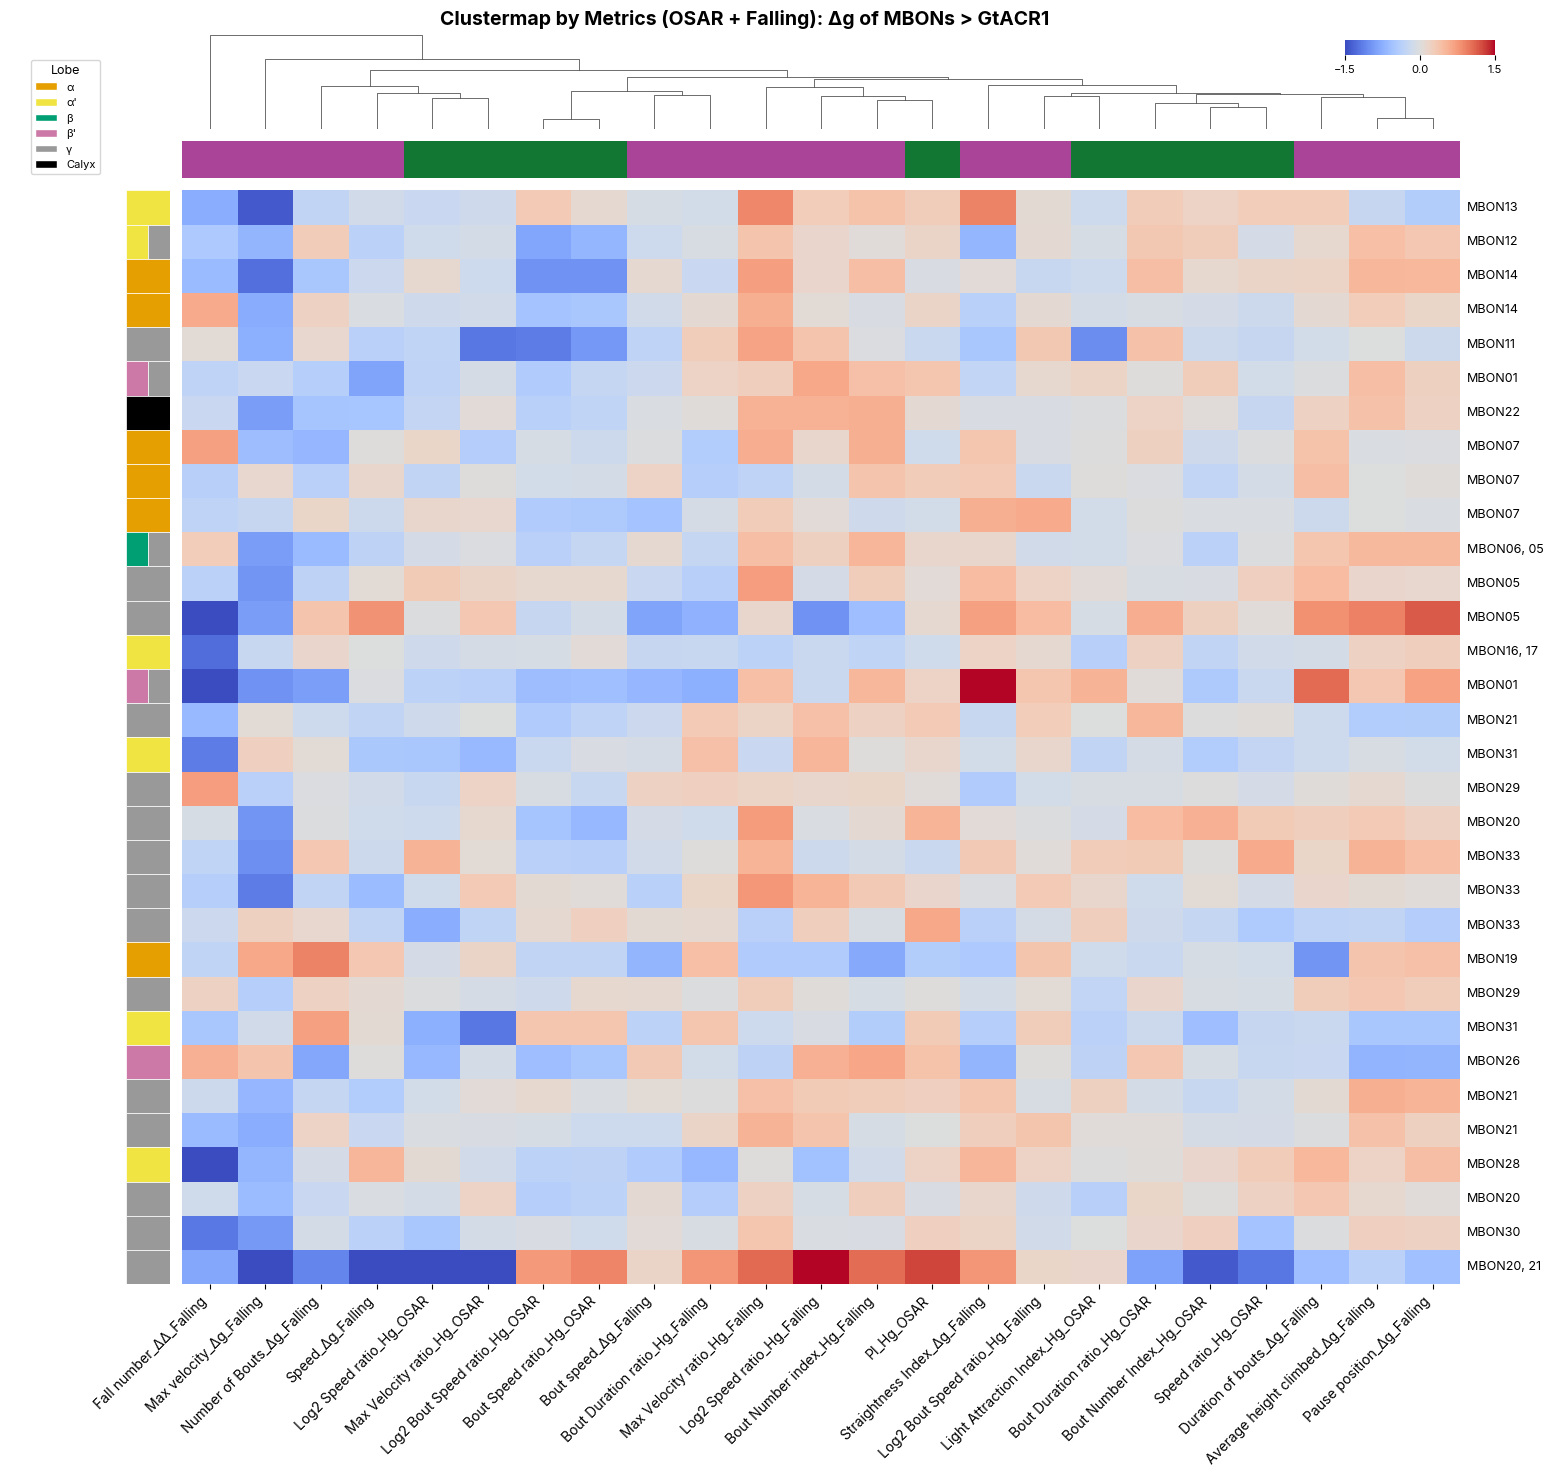

In [83]:
# Clustermap by Metrics (column clustering)
plt.rcParams["font.family"] = "Inter"

g2 = sns.clustermap(df_cluster_data, cmap=colormap, method='weighted', metric='euclidean', 
                    yticklabels=False, xticklabels=list(df_cluster_data.columns), vmin=-1.5, vmax=1.5,
                    row_cluster=False, col_cluster=True, annot=False,
                    row_colors=['#FFFFFF'] * len(df_cluster_data),
                    col_colors=col_colors,
                    dendrogram_ratio=(dendrogram_size, dendrogram_size),
                    cbar_kws=dict(orientation='horizontal', ticks=[-1.5, 0, 1.5]), 
                    figsize=(fig_width, fig_height), cbar_pos=(0.9, 0.99, 0.10, 0.01))

# Colorbar tick size
cbar = g2.ax_cbar
cbar.tick_params(labelsize=8)

# Get positions
row_colors_pos = g2.ax_row_colors.get_position()
heatmap_pos = g2.ax_heatmap.get_position()
col_colors_pos = g2.ax_col_colors.get_position()
col_dendro_pos = g2.ax_col_dendrogram.get_position()

# Horizontal gaps: shift heatmap right (away from row_colors)
g2.ax_heatmap.set_position([heatmap_pos.x0 + gap, heatmap_pos.y0, heatmap_pos.width - gap, heatmap_pos.height])

# Vertical gaps: shift col_colors up (away from heatmap), shift col_dendrogram up (away from col_colors)
g2.ax_col_colors.set_position([col_colors_pos.x0 + gap, col_colors_pos.y0 + gap, col_colors_pos.width - gap, col_colors_pos.height])
g2.ax_col_dendrogram.set_position([col_dendro_pos.x0 + gap, col_dendro_pos.y0 + gap*2, col_dendro_pos.width - gap, col_dendro_pos.height])

# Draw proportional lobe colors
ax_row_colors = g2.ax_row_colors
row_order = list(range(len(df_cluster)))
ax_row_colors.clear()
ax_row_colors.set_xlim(0, 1)
ax_row_colors.set_ylim(0, len(row_order))
ax_row_colors.invert_yaxis()
ax_row_colors.axis('off')

for i, idx in enumerate(row_order):
    lobes = df_cluster['Lobes_parsed'].iloc[idx]
    n_lobes = len(lobes) if lobes else 1
    for j, lobe in enumerate(lobes):
        rect = plt.Rectangle((j / n_lobes, i), 1 / n_lobes, 1, facecolor=lobe_palette.get(lobe, '#FFFFFF'), edgecolor='white', linewidth=0.5)
        ax_row_colors.add_patch(rect)

# Labels and title
g2.ax_heatmap.set_ylabel('')
g2.ax_heatmap.set_xticklabels(g2.ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=10)
g2.fig.suptitle(f'Clustermap by Metrics ({mode_label}): Δg of MBONs > {responderrename}', weight='bold', fontsize=14, y=1.02)

for i in range(len(df_cluster)):
    g2.ax_heatmap.text(1.005, i + 0.5, df_cluster['Name_short'].iloc[i], ha='left', va='center', fontsize=9, transform=g2.ax_heatmap.get_yaxis_transform())

# Legend
legend_elements = [plt.Rectangle((0,0),1,1, facecolor=c, edgecolor='white', label=l) for l, c in lobe_palette.items() if l != 'Unknown']
g2.fig.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0.02, 0.99), title='Lobe', fontsize=8, title_fontsize=9)

plt.show()

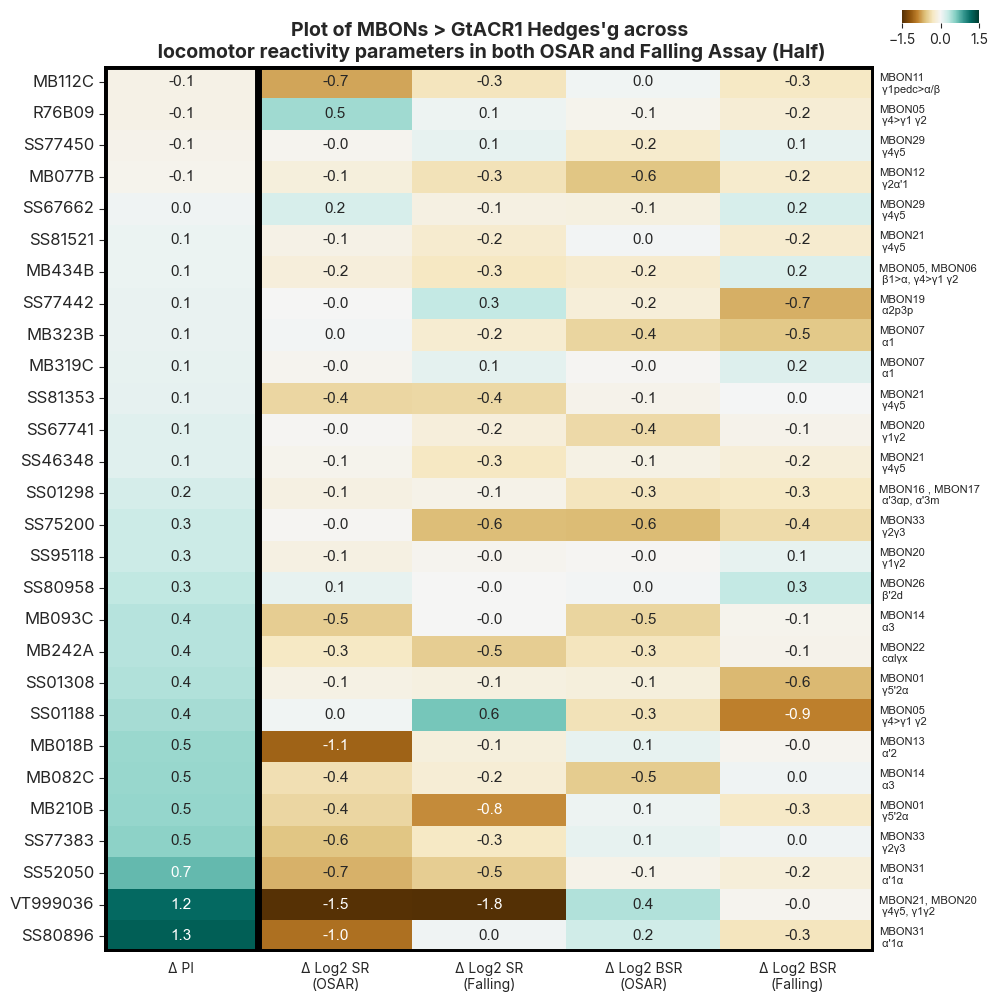

Generated heatmap for Half condition


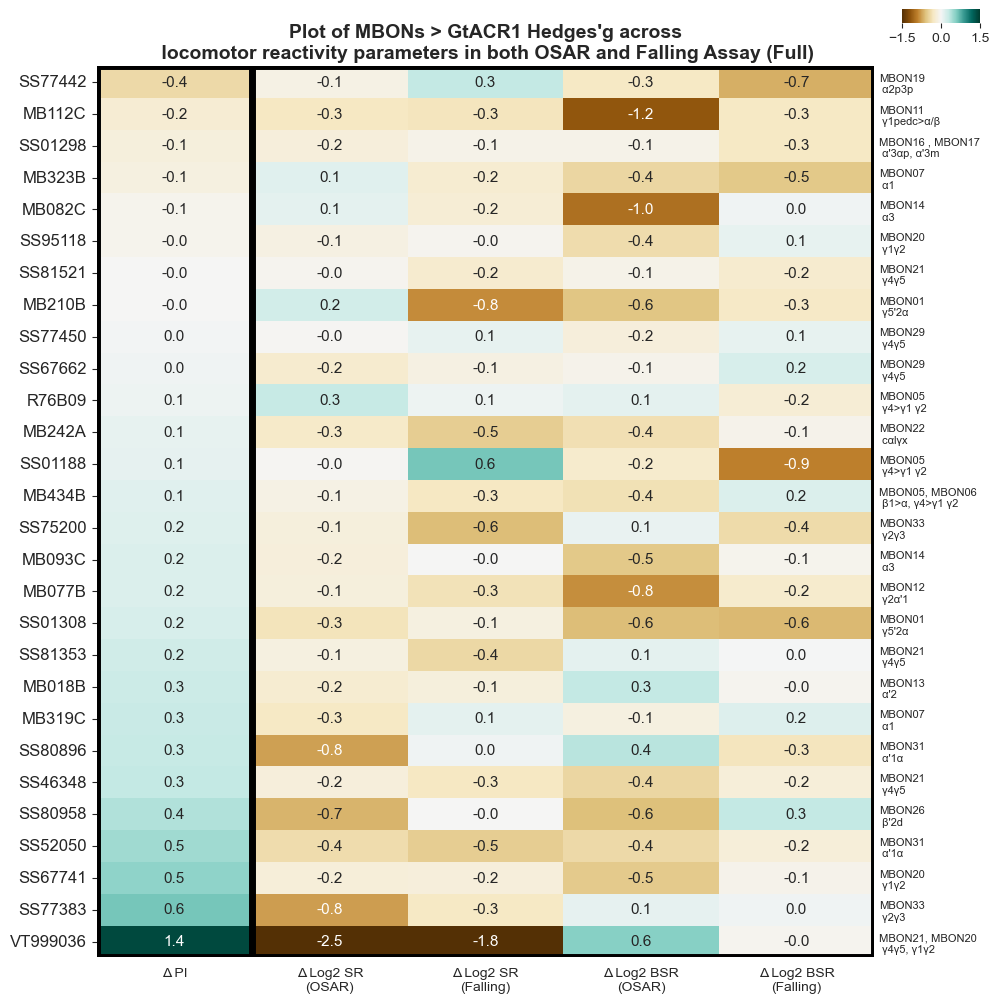

Generated heatmap for Full condition


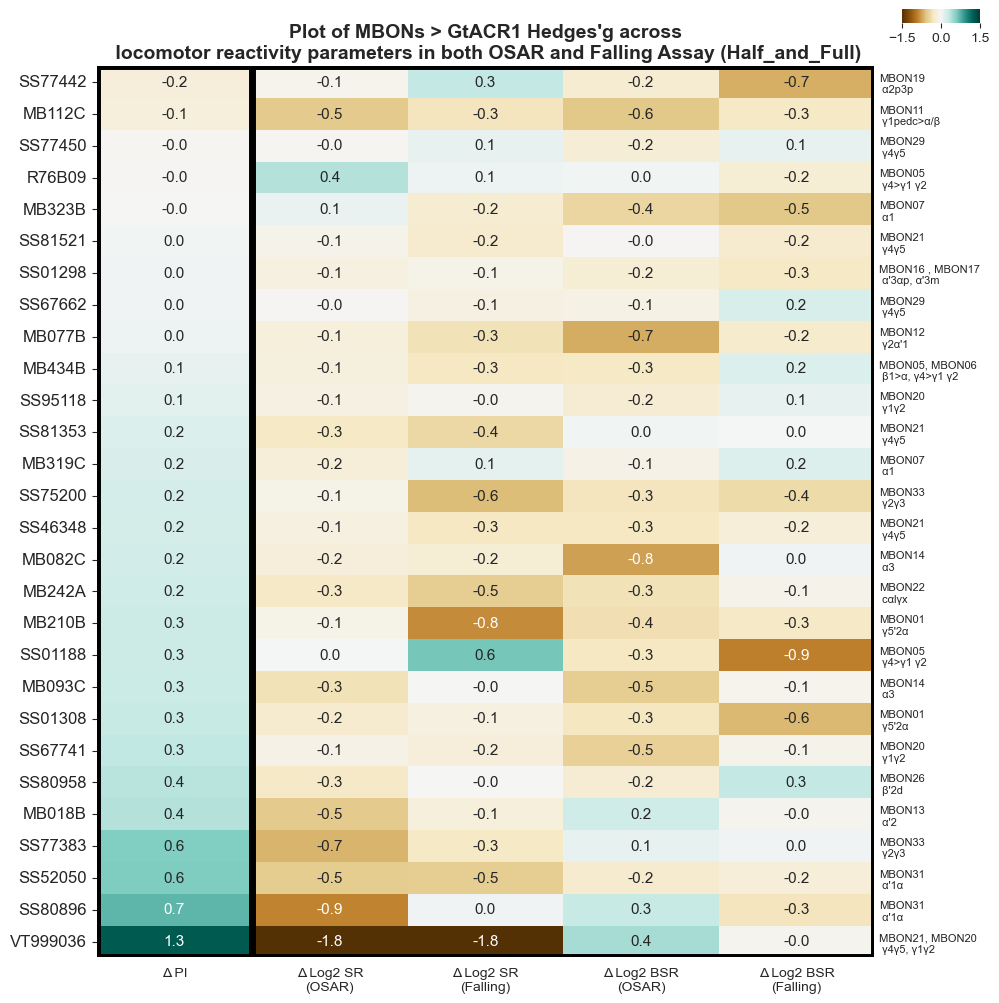

Generated heatmap for Half_and_Full condition


In [24]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

responder = "ACR"

plt.rcParams["font.family"] = "Inter"

# Define the three condition files
conditions = ['Half', 'Full', 'Half_and_Full']

for condition in conditions:
    # Read the specific condition file
    totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar climbing\\Totalcomparisonofallmetrics-" + condition + ".xlsx")
    
    osarmatchdf = totalmetriccomparison.copy()
    
    if responder == 'Chrimson2':
        responderrename = "CsChrimson"
        df_specificmbon = osarmatchdf[osarmatchdf['responder']=="Chrimson2"].sort_values(by="PI_Δg_OSAR", ascending=True).reset_index(drop=True)
        colormap = 'RdGy'
    
    if responder == 'ACR':
        responderrename = "GtACR1"
        df_specificmbon = osarmatchdf[osarmatchdf['responder']=="ACR"].sort_values(by="PI_Δg_OSAR", ascending=True).reset_index(drop=True)
        colormap = 'BrBG'
    
    df00 = df_specificmbon.set_index(['genotypeandresponder'])
    
    fig1, ax3 = plt.subplots(figsize=(10,10))     
    
    # Adding extra axes label
    lobloclst = []
    mbonloclst = []
    df500 = df00.copy()
    for n in df00['MBON']:    
        lobloclst.append(lobelocation[lobelocation['MBON'] == n]['Lobe_location'].values[0])
        mbonloclst.append(lobelocation[lobelocation['MBON'] == n]['MBON number'].values[0])
    df500['Lobe'] = lobloclst
    df500['Name'] = mbonloclst
    
    df00 = df00.drop(['MBON', 'responder'], axis=1)
    
    # Single responder labeling
    newdf500 = pd.DataFrame()
    naming = df500['Name'].to_frame().rename(columns={"Name": ""})
    lobing = df500['Lobe'].to_frame().rename(columns={"Lobe": ""})
    newlabel = (naming.values + "\n " + lobing.values).tolist()
    newdf500['Merge'] = newlabel
    
    # New labels for heatmap
    df00 = df00[['PI_Δg_OSAR', 'Log2 Speed ratio_Δg_OSAR', 'Log2 Speed ratio_Δg_Climbing', 
                 'Log2 Bout Speed ratio_Δg_OSAR', 'Log2 Bout Speed ratio_Δg_Climbing']]
    xticklabeldf = df00.rename(columns={
        'PI_Δg_OSAR': 'Δ PI',
        'Log2 Speed ratio_Δg_OSAR': "Δ Log2 SR (OSAR)",
        'Log2 Bout Speed ratio_Δg_OSAR': "Δ Log2 BSR (OSAR)",
        'Log2 Bout Speed ratio_Δg_Climbing': 'Δ Log2 BSR (Climbing)',
        'Log2 Speed ratio_Δg_Climbing': 'Δ Log2 SR (Climbing)'
    })
    xticklabellist = xticklabeldf.columns.tolist()
    yticklabels = [label.split("_")[0] for label in df00.index]
    
    # Colorbar
    cax = inset_axes(ax3,
                     width="10%",
                     height="1.5%",
                     loc='lower right',
                     bbox_to_anchor=(0.1, 1.08, 1, 1),
                     bbox_transform=ax3.transAxes,
                     borderpad=-2,
                     )
    
    sns.set_style("whitegrid", {'axes.grid': False})           
    j7 = sns.heatmap(df00, ax=ax3, annot=True, fmt=".1f", vmin=-1.5, vmax=1.5, cmap=colormap, 
                     linewidths=0.0, edgecolor="none", xticklabels=xticklabellist, yticklabels=yticklabels,
                     clip_on=False, cbar_ax=cax, cbar_kws=dict(orientation="horizontal", ticks=[-1.5, 0, 1.5]), 
                     annot_kws={"size": 11})
    j7.set_ylabel('')
    j7.set_yticklabels(j7.get_yticklabels(), va='center', rotation=0, fontsize=12)
    j7.set_xticklabels(j7.get_xticklabels(), rotation=0, fontsize=10)
    NLProcessing.wrap_labels(j7, 10)
    
    # Drawing the frame
    j7.axhline(y=0, color='k', linewidth=5) 
    j7.axhline(y=len(df00), color='k', linewidth=5) 
    j7.axvline(x=0, color='k', linewidth=5) 
    j7.axvline(x=1, color='k', linewidth=5) 
    j7.axvline(x=len(df00.columns), color='k', linewidth=5) 
    
    # Secondary axes
    j8 = j7.twinx()
    j8.set_ylim([0, j7.get_ylim()[0]])
    j8.set_yticks(j7.get_yticks())
    j8.tick_params(length=0)
    
    # Y labels for mbon lobes and naming
    labellinglist = newdf500['Merge'].iloc[::-1]
    labelledlist = []
    for n in labellinglist:
        labelledlist.extend(n)
        
    j8.set_yticklabels(labelledlist, fontsize=8)
    j8.spines['top'].set_visible(False)
    j8.spines['right'].set_visible(False)
    j8.spines['bottom'].set_visible(False)
    j8.spines['left'].set_visible(False)
    
    j7.set_title(f"Plot of MBONs > {responderrename} Hedges'g across\n locomotor reactivity parameters in both OSAR and Climbing Assay ({condition})", 
                 x=0.5, weight='bold', fontsize=14)
    
    fig1.tight_layout()
    
    plt.savefig(filesavedir + date + "_" + responder + "_hedgesgheatmap_" + condition + ".png", dpi=1200)
    plt.savefig(filesavedir + date + "_" + responder + "_hedgesgheatmap_" + condition + ".svg")
    
    plt.show()
    
    print(f"Generated heatmap for {condition} condition")